## Data preprocessing

Importing necessary libraries

In [1]:
import os
import numpy as np
from scipy.io import loadmat
import pandas as pd
import shutil

Setting up the paths

In [5]:
# based_dir: the root directory of the project
# raw_data_root_path: the path to the raw data
# preprocessed_data_root_path: the path to the preprocessed data
# Todo: define the base directory of the project
base_dir = os.path.abspath(os.getcwd())
raw_data_root_path = os.path.join(base_dir, 'data', 'raw')
preprocessed_data_root_path = os.path.join(base_dir, 'data', 'preprocessed')

Defining the preprocessing function

In [6]:
# read_nasa: function to read the raw NASA data and save the preprocessed data
# 1. Extract the discharge capacity and cycle number
# 2. Calculate the state of health (SOH) of each cycle
# 3. Save the preprocessed data as csv files
# file_dir: the directory of the raw data
# save_path: the directory to save the preprocessed data

def read_nasa(file_dir, save_path):
    # nominal capacity given in the task
    nominal_capacity = 2.0  # [Ah]

    os.makedirs(save_path, exist_ok=True)

    for file_name in os.listdir(file_dir):
        if not file_name.endswith(".mat"):
            continue

        cell_name = file_name[:-4]  # remove ".mat"

        cycle_list = []
        discharge_capacity_list = []
        cycle_counter = 0

        # load the mat file
        raw_mat = loadmat(os.path.join(file_dir, file_name))

        # IMPORTANT: cycle structure is nested like this:
        # raw_mat[cell_name]['cycle'] -> (1,1) object
        # [0,0] -> (1, N) struct
        # [0]   -> (N,) struct you can iterate over
        raw_data = raw_mat[cell_name]['cycle'][0, 0][0]

        for i in range(len(raw_data)):
            cyc_type = raw_data[i]['type'][0]
            if cyc_type == 'discharge':
                cycle_counter += 1
                cap = raw_data[i]['data'][0, 0]['Capacity'][0, 0]
                cycle_list.append(cycle_counter)
                discharge_capacity_list.append(float(cap))

        cycle = np.array(cycle_list)
        discharge_data = np.array(discharge_capacity_list)

        # SOH = Capacity / nominal_capacity
        soh = discharge_data / nominal_capacity

        save_df = pd.DataFrame({
            'Cycle': cycle,
            'Capacity': discharge_data,
            'SOH': soh
        })

        save_df.to_csv(os.path.join(save_path, cell_name + '.csv'), index=False)
        print(file_name + ' preprocessed!')



Read the raw data and save the preprocessed data

In [7]:
read_nasa(file_dir=raw_data_root_path, save_path=preprocessed_data_root_path)

B0018.mat preprocessed!
B0005.mat preprocessed!
B0006.mat preprocessed!
B0007.mat preprocessed!


Demonstration of the preprocessed data

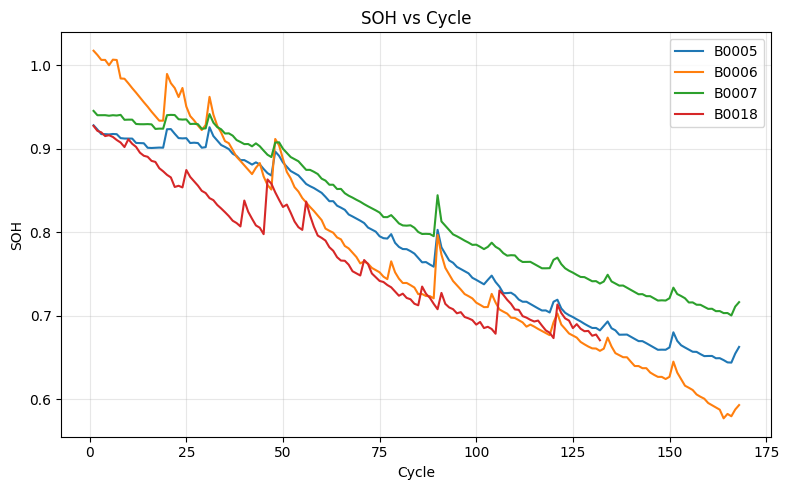

In [8]:
# Todo: plot SOH vs Cycle number of the four cells in one figure
import matplotlib.pyplot as plt

cell_names = ['B0005', 'B0006', 'B0007', 'B0018']
plt.figure(figsize=(8, 5))
for cell in cell_names:
    file_path = os.path.join(preprocessed_data_root_path, f'{cell}.csv')
    if not os.path.exists(file_path):
        continue
    df = pd.read_csv(file_path)
    plt.plot(df['Cycle'], df['SOH'], label=cell)

plt.xlabel('Cycle')
plt.ylabel('SOH')
plt.title('SOH vs Cycle')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Split the data into training, validation, and test sets

In [9]:
# split_data: function to split the preprocessed data into training, validation, and test sets
# preprocessed_path: the directory of the preprocessed data
# training set: B0006, B0007
# validation set: B0005
# test set: B0018

def split_data(preprocessed_path):
    # create the training, validation, and test directories
    train_path = os.path.join(preprocessed_path, 'training')
    val_path = os.path.join(preprocessed_path, 'validation')
    test_path = os.path.join(preprocessed_path, 'test')
    os.makedirs(train_path, exist_ok=True)
    os.makedirs(val_path, exist_ok=True)
    os.makedirs(test_path, exist_ok=True)

    train_cells = {'B0006', 'B0007'}
    val_cells = {'B0005'}
    test_cells = {'B0018'}

    # iterate through all files in the preprocessed directory
    for file_name in os.listdir(preprocessed_path):
        file_path = os.path.join(preprocessed_path, file_name)
        if not (os.path.isfile(file_path) and file_name.endswith('.csv')):
            continue
        cell_name = file_name[:-4]  # remove the '.csv' extension
        # Todo: check cell name and move the profile to the corresponding set
        if cell_name in train_cells:
            shutil.move(src=file_path, dst=os.path.join(train_path, file_name))
            print(file_name + ' moved to training set!')
        elif cell_name in val_cells:
            shutil.move(src=file_path, dst=os.path.join(val_path, file_name))
            print(file_name + ' moved to validation set!')
        elif cell_name in test_cells:
            shutil.move(src=file_path, dst=os.path.join(test_path, file_name))
            print(file_name + ' moved to test set!')

In [10]:
split_data(preprocessed_data_root_path)

B0007.csv moved to training set!
B0006.csv moved to training set!
B0005.csv moved to validation set!
B0018.csv moved to test set!
